# KDSC Replication (IROS 2025 baseline)

Reproduce the **Kinematic Driving Style Clustering (KDSC)** baseline from the original paper so we can compare it against our approach.

**Paper recipe (as we will implement it):**
1. Per-agent features: `max_abs_acceleration`, `var_acceleration`, `var_speed`, `gamma`.
2. Minimal preprocessing: drop NaN/stationary/non-vehicle rows. **No** stop-and-go filter, **no** physical-sanity cap, **no** feature-importance selection.
3. Standardize features.
4. **Agglomerative clustering** (Ward linkage), `K=2`.
5. Label the cluster with the higher mean on the 4 KDSC features as `aggressive`.

Runs on both AV2 and Waymo via the `DATASET` switch at the top. Outputs go to `artifacts/kdsc_replication/<dataset>/` so this notebook's labels live alongside (and never overwrite) the labels produced by our main pipeline.

In [4]:
from __future__ import annotations
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

# -------- DATASET SWITCH --------
DATASET = 'av2'         # 'av2' or 'waymo'
RANDOM_STATE = 42
# Agglomerative is O(n^2) memory: subsample for the fit, then assign all points
# by nearest standardized-centroid (the paper's experiments are also in this regime).
MAX_FIT_SAMPLES = 20000
# --------------------------------

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

if DATASET == 'av2':
    TABLES = REPO_ROOT / 'artifacts' / 'phase1' / 'tables'
    TRAIN_CSV = TABLES / 'av2_train_feature_table.csv'
    VAL_CSV   = TABLES / 'av2_val_feature_table.csv'
    SPLIT_BY_SCENARIO = False  # AV2 already ships separate train/val tables
elif DATASET == 'waymo':
    TABLES = REPO_ROOT / 'artifacts' / 'phase1_waymo' / 'tables'
    TRAIN_CSV = TABLES / 'waymo_val_feature_table.csv'  # we 80/20-split this
    VAL_CSV   = TRAIN_CSV
    SPLIT_BY_SCENARIO = True
    TRAIN_FRACTION = 0.8
else:
    raise ValueError(f'DATASET must be "av2" or "waymo", got {DATASET!r}')

OUT_DIR = REPO_ROOT / 'artifacts' / 'kdsc_replication' / DATASET
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset    :', DATASET)
print('Train table:', TRAIN_CSV, '| exists:', TRAIN_CSV.exists())
print('Val table  :', VAL_CSV,   '| exists:', VAL_CSV.exists())
print('Outputs    :', OUT_DIR)

Dataset    : av2
Train table: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/phase1/tables/av2_train_feature_table.csv | exists: True
Val table  : /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/phase1/tables/av2_val_feature_table.csv | exists: True
Outputs    : /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/kdsc_replication/av2


## 1. Load per-agent feature tables

Same feature tables our main pipeline reads. For Waymo we split the validation feature table 80/20 by `scenario_id` (matches our main Waymo notebook).

In [5]:
if SPLIT_BY_SCENARIO:
    raw = pd.read_csv(TRAIN_CSV)
    scenarios = raw['scenario_id'].drop_duplicates().to_numpy()
    rng_split = np.random.default_rng(RANDOM_STATE)
    rng_split.shuffle(scenarios)
    n_train = int(len(scenarios) * TRAIN_FRACTION)
    train_ids = set(scenarios[:n_train])
    val_ids   = set(scenarios[n_train:])
    train_raw = raw[raw['scenario_id'].isin(train_ids)].copy()
    val_raw   = raw[raw['scenario_id'].isin(val_ids)].copy()
else:
    train_raw = pd.read_csv(TRAIN_CSV)
    val_raw   = pd.read_csv(VAL_CSV)

print('train_raw:', train_raw.shape)
print('val_raw  :', val_raw.shape)
train_raw.head(3)

train_raw: (45818, 62)
val_raw  : (22979, 62)


,dataset,split,scenario_id,center_objects_id,center_objects_type,trajectory_type,kalman_difficulty_2s,kalman_difficulty_4s,kalman_difficulty_6s,avg_speed,...,cv_miss_rate,mtr_minade6,mtr_minfde6,mtr_brier_minade6,mtr_brier_minfde6,mtr_miss_rate,mtr_meanfde6_weighted,mtr_meanfde6_unweighted,mtr_best_mode_prob,mtr_best_fde_mode_idx
0,av2,train,c963ef91-d586-4a77-96d1-f3d93d0b2279,175794,1,0,0.101435,0.223603,0.309233,9.817317e-08,...,0.0,0.071032,0.039199,0.071185,0.039352,0.0,0.116423,10.445385,0.987651,0
1,av2,train,2606cea6-a2bc-4535-aa66-b1abce550800,107772,1,1,5.763917,16.740121,31.959041,9.620359e+00,...,1.0,0.507675,1.602169,1.025032,2.119526,0.0,6.232411,10.895061,0.280724,1
2,av2,train,faa84278-8c91-40bd-b6a1-8a863fb5fe1c,35749,1,1,0.168318,1.975820,5.900208,3.611795e+00,...,1.0,0.569410,0.974817,0.575181,0.980589,0.0,1.226938,13.688190,0.924029,0


## 2. Minimal cleaning (paper-style)

The paper does not describe outlier removal beyond standardization. To make this a fair *baseline* we apply only the obvious sanity drops:

- drop rows where any of the 4 KDSC features is NaN/inf,
- drop `is_stationary` rows (a stationary agent has no driving style),
- vehicle-only (`center_objects_type == 'vehicle'`) when that column exists.

**Crucially:** no stop-and-go filter, no physical-sanity caps, no Mahalanobis envelope. Everything our main pipeline adds on top of the paper is intentionally **off** here.

In [6]:
# Paper's 4 features. Our feature table calls max_abs_acceleration `max_abs_accel`.
KDSC_FEATURES = ['max_abs_accel', 'var_acceleration', 'var_speed', 'gamma']
VEHICLE_TYPE_CODE = 1  # `center_objects_type` is an int code; 1 == vehicle

def minimal_clean(df: pd.DataFrame, name: str) -> pd.DataFrame:
    n0 = len(df)
    out = df.copy()
    drops = {}

    if 'center_objects_type' in out.columns:
        n = len(out)
        types = pd.to_numeric(out['center_objects_type'], errors='coerce')
        out = out[types == VEHICLE_TYPE_CODE]
        drops['non_vehicle'] = n - len(out)

    if 'is_stationary' in out.columns:
        n = len(out)
        out = out[~out['is_stationary'].astype(bool)]
        drops['stationary'] = n - len(out)

    n = len(out)
    out = out.dropna(subset=KDSC_FEATURES)
    out = out[np.isfinite(out[KDSC_FEATURES]).all(axis=1)]
    drops['nan_or_inf'] = n - len(out)

    print(f'{name:5s}  {n0} -> {len(out)}  '
          f'(dropped {n0 - len(out)}, {(n0 - len(out)) / max(n0, 1):.1%})')
    print(pd.DataFrame([{'reason': k, 'count': v} for k, v in drops.items()])
          .to_string(index=False))
    return out.reset_index(drop=True)

train_clean = minimal_clean(train_raw, 'train')
val_clean   = minimal_clean(val_raw,   'val')

train  45818 -> 43696  (dropped 2122, 4.6%)
     reason  count
non_vehicle      0
 stationary   2122
 nan_or_inf      0
val    22979 -> 21809  (dropped 1170, 5.1%)
     reason  count
non_vehicle      0
 stationary   1170
 nan_or_inf      0


## 3. Standardize and fit Agglomerative clustering (K=2)

`StandardScaler` is fit on train and applied to val. Agglomerative clustering is `O(n^2)` in memory, so we fit on a random subsample of up to `MAX_FIT_SAMPLES` train rows, then compute each cluster's standardized centroid and assign **all** train + val rows by nearest centroid. This is the standard scalable variant of agglomerative clustering and preserves the paper's linkage choice.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K = 2

Xtr = train_clean[KDSC_FEATURES].astype(float).to_numpy()
Xva = val_clean[KDSC_FEATURES].astype(float).to_numpy()

scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)

rng = np.random.default_rng(RANDOM_STATE)
if len(Xtr_s) > MAX_FIT_SAMPLES:
    fit_idx = rng.choice(len(Xtr_s), size=MAX_FIT_SAMPLES, replace=False)
    print(f'Fitting agglomerative on subsample of {MAX_FIT_SAMPLES} / {len(Xtr_s)} train rows')
else:
    fit_idx = np.arange(len(Xtr_s))
    print(f'Fitting agglomerative on all {len(Xtr_s)} train rows')

Xfit = Xtr_s[fit_idx]
agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
fit_lbl = agg.fit_predict(Xfit)

# Standardized centroids per cluster, then assign every row to its nearest centroid.
centroids = np.stack([Xfit[fit_lbl == k].mean(axis=0) for k in range(K)])

def assign(X):
    d = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    return d.argmin(axis=1)

tr_lbl = assign(Xtr_s)
va_lbl = assign(Xva_s)

Fitting agglomerative on subsample of 20000 / 43696 train rows


In [8]:
# Label the cluster with the higher mean on the 4 KDSC features as aggressive.
score_per_cluster = (
    pd.DataFrame(Xtr_s, columns=KDSC_FEATURES)
      .assign(_c=tr_lbl)
      .groupby('_c')
      .mean()
      .mean(axis=1)
)
agg_cluster = int(score_per_cluster.idxmax())
label_map = {agg_cluster: 'aggressive', 1 - agg_cluster: 'normal'}
print('Cluster scores (standardized mean over 4 KDSC features):')
print(score_per_cluster.round(3))
print('Cluster -> label:', label_map)

train_clean['cluster_id_K2'] = tr_lbl
val_clean['cluster_id_K2']   = va_lbl
train_clean['style_label_kdsc'] = pd.Series(tr_lbl, index=train_clean.index).map(label_map)
val_clean['style_label_kdsc']   = pd.Series(va_lbl, index=val_clean.index).map(label_map)

print('\nTrain cluster sizes:')
print(train_clean['style_label_kdsc'].value_counts())
print('\nVal cluster sizes:')
print(val_clean['style_label_kdsc'].value_counts())

Cluster scores (standardized mean over 4 KDSC features):
_c
0    -0.031
1    10.514
dtype: float64
Cluster -> label: {1: 'aggressive', 0: 'normal'}

Train cluster sizes:
style_label_kdsc
normal        43567
aggressive      129
Name: count, dtype: int64

Val cluster sizes:
style_label_kdsc
normal        21725
aggressive       84
Name: count, dtype: int64


In [9]:
# Internal metrics on the standardized 4-feature space (sample silhouette).
sub = rng.choice(len(Xtr_s), size=min(8000, len(Xtr_s)), replace=False)
metrics = {
    'dataset': DATASET,
    'features': KDSC_FEATURES,
    'linkage': 'ward',
    'n_train': int(len(tr_lbl)),
    'n_val':   int(len(va_lbl)),
    'fit_subsample': int(len(fit_idx)),
    'silhouette':        float(silhouette_score(Xtr_s[sub], tr_lbl[sub])),
    'davies_bouldin':    float(davies_bouldin_score(Xtr_s, tr_lbl)),
    'calinski_harabasz': float(calinski_harabasz_score(Xtr_s, tr_lbl)),
    'label_map': {int(k): v for k, v in label_map.items()},
    'aggressive_share_train': float((train_clean['style_label_kdsc'] == 'aggressive').mean()),
    'aggressive_share_val':   float((val_clean['style_label_kdsc']   == 'aggressive').mean()),
}
print(json.dumps(metrics, indent=2))
with open(OUT_DIR / 'kdsc_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'kdsc_agglomerative_K2.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'centroids_standardized': centroids,
        'features': KDSC_FEATURES,
        'label_map': {int(k): v for k, v in label_map.items()},
        'linkage': 'ward',
        'fit_subsample_size': int(len(fit_idx)),
    }, f)

{
  "dataset": "av2",
  "features": [
    "max_abs_accel",
    "var_acceleration",
    "var_speed",
    "gamma"
  ],
  "linkage": "ward",
  "n_train": 43696,
  "n_val": 21809,
  "fit_subsample": 20000,
  "silhouette": 0.9274302646345561,
  "davies_bouldin": 0.5761434981530329,
  "calinski_harabasz": 26237.61422318512,
  "label_map": {
    "1": "aggressive",
    "0": "normal"
  },
  "aggressive_share_train": 0.00295221530574881,
  "aggressive_share_val": 0.0038516208904580676
}


## 4. Cluster profile and feature distributions

Same diagnostics we show for our main clustering, restricted to the 4 KDSC features so the comparison is apples-to-apples.

In [10]:
PROFILE_FEATURES = list(dict.fromkeys(KDSC_FEATURES + [
    'avg_speed', 'max_speed',
    'max_abs_long_accel', 'max_abs_lat_accel',
    'max_abs_jerk', 'max_abs_long_jerk', 'max_abs_lat_jerk',
    'hard_brake_count', 'hard_accel_count',
    'lateral_g_spike_count', 'high_jerk_count',
    'max_abs_heading_rate',
]))
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in train_clean.columns]

z = (train_clean[PROFILE_FEATURES] - train_clean[PROFILE_FEATURES].mean()) / train_clean[PROFILE_FEATURES].std()
z['style_label_kdsc'] = train_clean['style_label_kdsc']
profile = z.groupby('style_label_kdsc')[PROFILE_FEATURES].mean().T
profile['delta'] = profile.get('aggressive', 0) - profile.get('normal', 0)
profile = profile.sort_values('delta', ascending=False)
profile.to_csv(OUT_DIR / 'kdsc_cluster_profile.csv')
profile.round(3)

style_label_kdsc,aggressive,normal,delta
var_acceleration,14.058,-0.042,14.100
gamma,13.238,-0.039,13.278
max_abs_long_jerk,12.791,-0.038,12.829
max_abs_jerk,12.519,-0.037,12.556
max_abs_long_accel,10.977,-0.033,11.009
max_abs_accel,10.918,-0.032,10.950
max_abs_lat_jerk,4.005,-0.012,4.017
var_speed,3.842,-0.011,3.853
hard_accel_count,2.778,-0.008,2.786
max_abs_lat_accel,2.690,-0.008,2.698


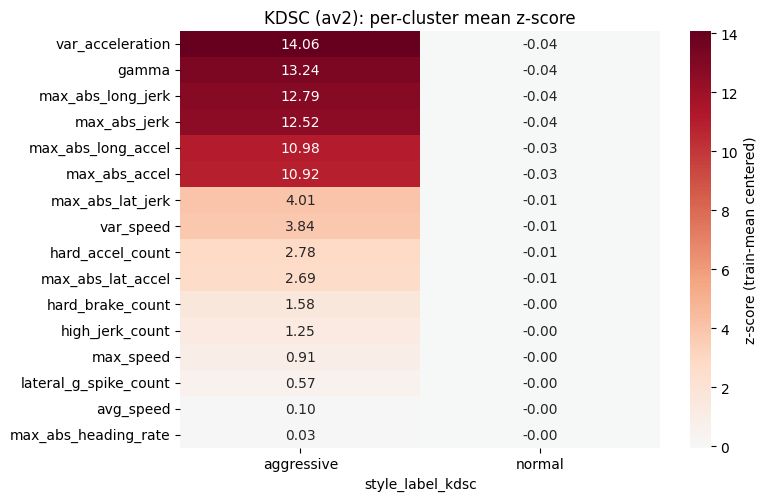

In [11]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(PROFILE_FEATURES))))
sns.heatmap(profile.drop(columns='delta'), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'z-score (train-mean centered)'})
ax.set_title(f'KDSC ({DATASET}): per-cluster mean z-score')
fig.tight_layout()
fig.savefig(FIG_DIR / 'kdsc_cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

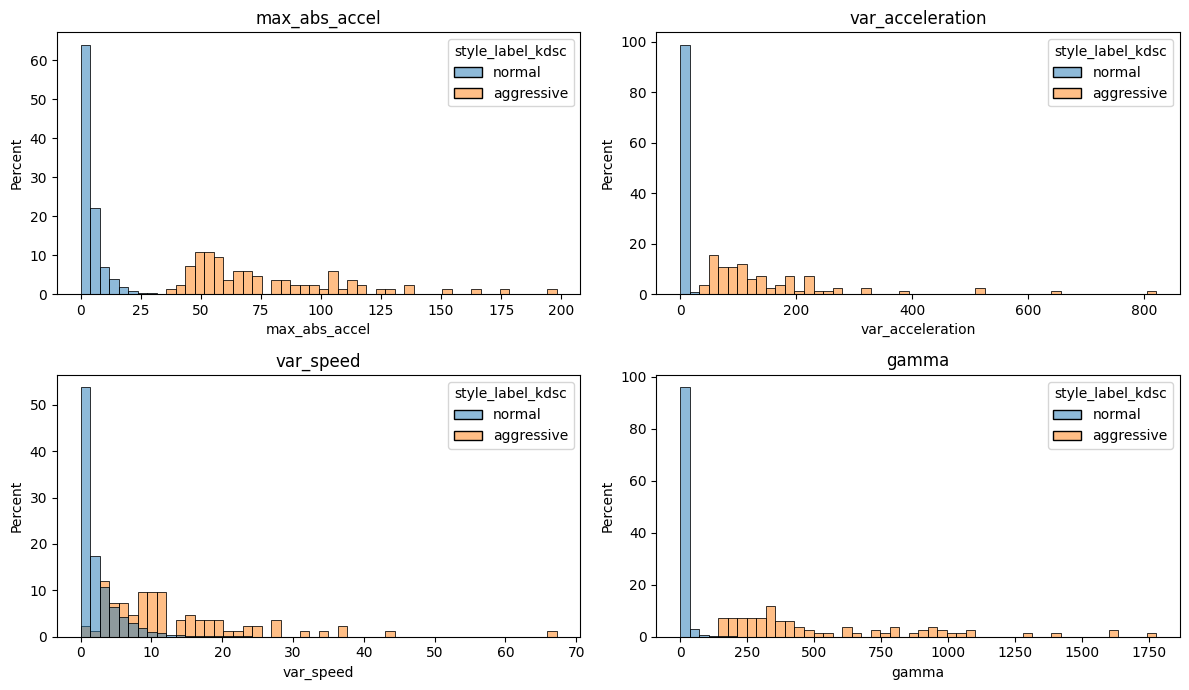

In [12]:
# Per-feature distributions (val) for the 4 KDSC features
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, feat in zip(axes.flat, KDSC_FEATURES):
    sns.histplot(data=val_clean, x=feat, hue='style_label_kdsc',
                 stat='percent', common_norm=False, bins=50, ax=ax)
    ax.set_title(feat)
fig.tight_layout()
fig.savefig(FIG_DIR / 'kdsc_feature_distributions_val.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Save labelled tables

These parquets are consumed by the comparison notebook (`clustering_comparison.ipynb`).

In [13]:
train_clean.to_parquet(OUT_DIR / f'{DATASET}_train_kdsc.parquet', index=False)
val_clean.to_parquet(OUT_DIR / f'{DATASET}_val_kdsc.parquet', index=False)
print('Wrote:')
for p in sorted(OUT_DIR.glob('*')):
    print(' ', p.relative_to(REPO_ROOT))

Wrote:
  artifacts/kdsc_replication/av2/av2_train_kdsc.parquet
  artifacts/kdsc_replication/av2/av2_val_kdsc.parquet
  artifacts/kdsc_replication/av2/figures
  artifacts/kdsc_replication/av2/kdsc_agglomerative_K2.pkl
  artifacts/kdsc_replication/av2/kdsc_cluster_profile.csv
  artifacts/kdsc_replication/av2/kdsc_metrics.json
